# Training Summary

Aggregates metrics from Mask2Former training runs in `output/` and renders cross-variant comparisons.

**Sync from HPC**: a keep-list in `.gitignore` tracks only the lightweight artifacts (`metrics.json`, `log.txt`, `inference/coco_instances_results.json`, etc.) — checkpoints (`*.pth`) and `vis/` overlays are excluded. On HPC: `git add output/ && git commit && git push`. Locally: `git pull`.

**Which runs are shown**: edit the `RUNS` allowlist in cell 2.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("output")
assert OUTPUT_DIR.exists(), f"{OUTPUT_DIR.resolve()} not found - run from repo root"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Run allowlist

Display name → directory name (under `output/`). Comment out a line to drop a run from every table and plot below.

In [2]:
RUNS = {
    "rgb":              "rgb_swin_tiny",
    "rgbd_early":       "rgbd_early_swin_tiny",
    "rgbd_bicma":       "rgbd_bicma_swin_tiny",
    # "rgbd_bicma_alpha": "rgbd_bicma_alpha_swin_tiny",  # enable when a full run is synced
    "rgbd_dca (K=0)":   "rgbd_dca_swin_tiny",
    "rgbd_dca (K=1)":   "rgbd_dca_1iter_swin_tiny",
}

missing = [(name, d) for name, d in RUNS.items() if not (OUTPUT_DIR / d / "metrics.json").exists()]
if missing:
    print("WARNING: metrics.json not found for:")
    for name, d in missing:
        print(f"  - {name}  ({OUTPUT_DIR / d})")

RUNS = {name: d for name, d in RUNS.items() if (OUTPUT_DIR / d / "metrics.json").exists()}
print(f"\n{len(RUNS)} runs will be loaded: {list(RUNS)}")


5 runs will be loaded: ['rgb', 'rgbd_early', 'rgbd_bicma', 'rgbd_dca (K=0)', 'rgbd_dca (K=1)']


## Loader

Detectron2 writes `metrics.json` as newline-delimited JSON. Each line is one record — either a training step (has `total_loss`) or an evaluation (has `segm/AP`). We split them into two long-format DataFrames per run.

In [3]:
def load_metrics(run_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read metrics.json (JSONL) and split into (train_df, eval_df)."""
    records = []
    with (run_dir / "metrics.json").open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    train_rows = [r for r in records if "total_loss" in r]
    eval_rows  = [r for r in records if "segm/AP" in r]

    train_df = pd.DataFrame(train_rows).sort_values("iteration").reset_index(drop=True)
    eval_df  = pd.DataFrame(eval_rows).sort_values("iteration").reset_index(drop=True)
    return train_df, eval_df


train_data = {}
eval_data  = {}
for name, dirname in RUNS.items():
    train_data[name], eval_data[name] = load_metrics(OUTPUT_DIR / dirname)
    print(f"{name:20s}  train={len(train_data[name]):4d} rows  eval={len(eval_data[name]):3d} rows  "
          f"max_iter={int(train_data[name]['iteration'].max())}")

rgb                   train= 256 rows  eval=  7 rows  max_iter=4999
rgbd_early            train= 259 rows  eval=  6 rows  max_iter=4999
rgbd_bicma            train= 500 rows  eval= 10 rows  max_iter=4999
rgbd_dca (K=0)        train= 250 rows  eval=  5 rows  max_iter=4999
rgbd_dca (K=1)        train= 250 rows  eval=  5 rows  max_iter=4999


## Summary table

Best-iter (by `segm/AP`) and final-iter eval metrics per run. Max value per column is highlighted.

In [4]:
METRIC_COLS = ["segm/AP", "segm/AP50", "segm/AP75", "segm/AP-redfruit", "segm/AP-greenfruit"]

rows = []
for name, eval_df in eval_data.items():
    if eval_df.empty:
        continue
    best = eval_df.loc[eval_df["segm/AP"].idxmax()]
    final = eval_df.iloc[-1]
    rows.append({
        "variant":    name,
        "best_iter":  int(best["iteration"]),
        "best_AP":    best["segm/AP"],
        "AP50":       best["segm/AP50"],
        "AP75":       best["segm/AP75"],
        "AP-red":     best["segm/AP-redfruit"],
        "AP-green":   best["segm/AP-greenfruit"],
        "final_iter": int(final["iteration"]),
        "final_AP":   final["segm/AP"],
    })

summary = pd.DataFrame(rows).set_index("variant")
summary.style.format("{:.2f}", subset=["best_AP", "AP50", "AP75", "AP-red", "AP-green", "final_AP"]) \
             .highlight_max(subset=["best_AP", "AP50", "AP75", "AP-red", "AP-green", "final_AP"], color="lightgreen")

,best_iter,best_AP,AP50,AP75,AP-red,AP-green,final_iter,final_AP
variant,,,,,,,,
rgb,1999,58.05,84.17,67.36,61.22,54.89,5000,55.31
rgbd_early,2999,57.31,86.54,65.97,60.81,53.80,5000,55.41
rgbd_bicma,5000,13.03,34.59,7.17,13.25,12.81,5000,13.03
rgbd_dca (K=0),3999,16.06,37.15,11.79,15.65,16.47,5000,16.01
rgbd_dca (K=1),999,57.58,85.25,65.02,61.67,53.49,5000,56.22


## AP curves over iterations

One line per variant. AP / AP50 / AP75 as side-by-side panels.

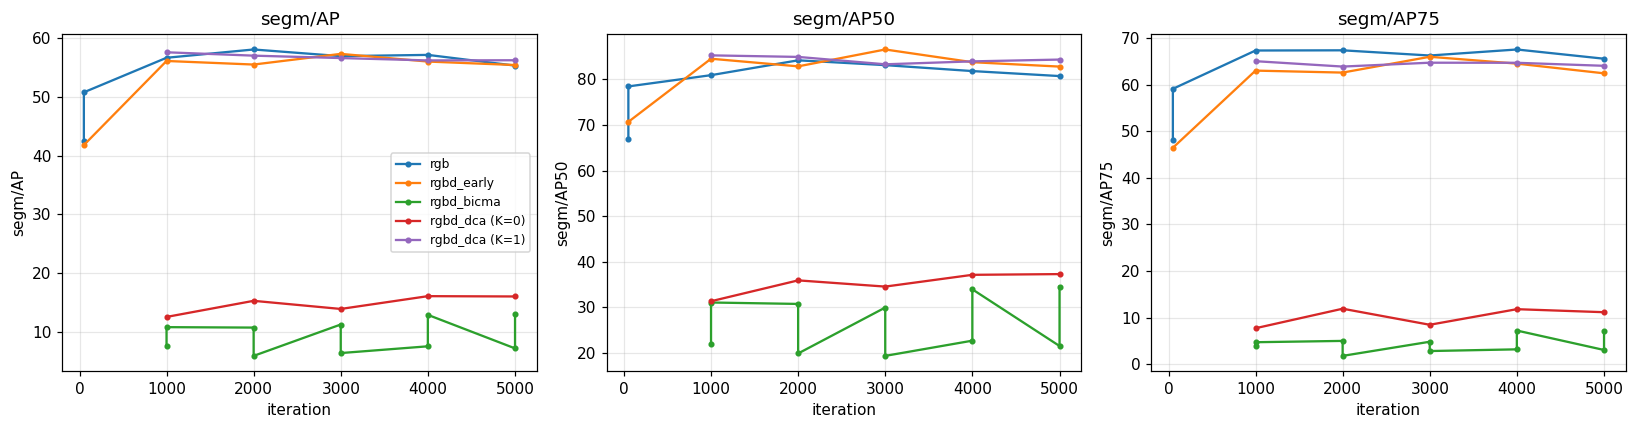

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric in zip(axes, ["segm/AP", "segm/AP50", "segm/AP75"]):
    for name, eval_df in eval_data.items():
        if eval_df.empty:
            continue
        ax.plot(eval_df["iteration"], eval_df[metric], marker="o", markersize=3, label=name)
    ax.set_title(metric)
    ax.set_xlabel("iteration")
    ax.set_ylabel(metric)
axes[0].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

## Per-class AP (red vs green)

Curves over iterations plus a final-iter grouped bar chart.

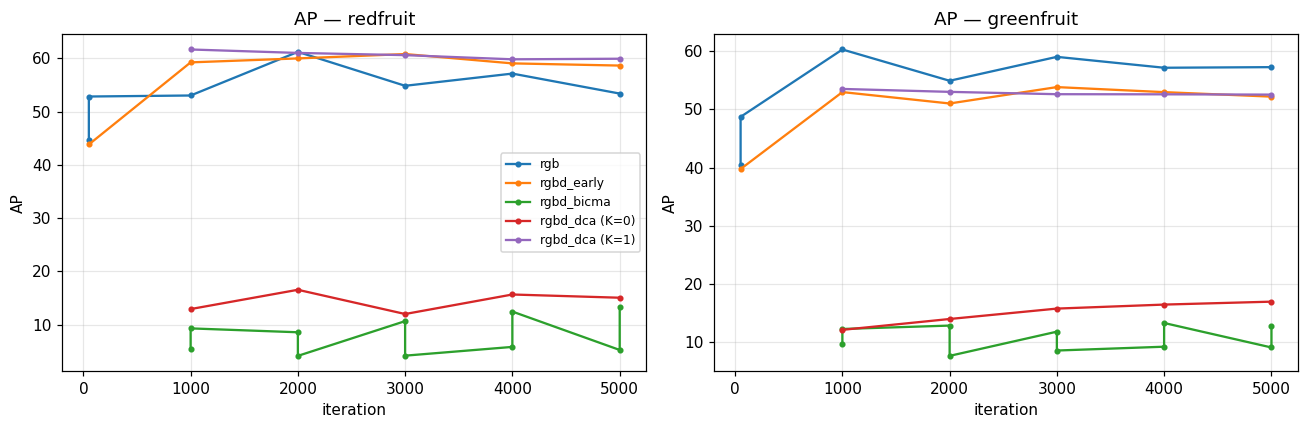

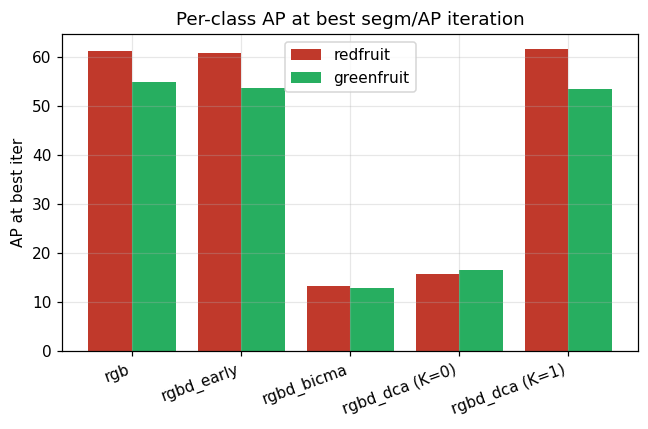

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, metric, title in zip(
    axes,
    ["segm/AP-redfruit", "segm/AP-greenfruit"],
    ["AP — redfruit", "AP — greenfruit"],
):
    for name, eval_df in eval_data.items():
        if eval_df.empty:
            continue
        ax.plot(eval_df["iteration"], eval_df[metric], marker="o", markersize=3, label=name)
    ax.set_title(title)
    ax.set_xlabel("iteration")
    ax.set_ylabel("AP")
axes[0].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

# Best-iter bar chart, red vs green per variant
names = list(summary.index)
red   = summary["AP-red"].values
green = summary["AP-green"].values
x = np.arange(len(names))
w = 0.4

fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(names)), 4))
ax.bar(x - w/2, red,   w, label="redfruit",   color="#c0392b")
ax.bar(x + w/2, green, w, label="greenfruit", color="#27ae60")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("AP at best iter")
ax.set_title("Per-class AP at best segm/AP iteration")
ax.legend()
fig.tight_layout()
plt.show()

## Training loss curves

`total_loss`, `loss_ce`, `loss_dice`, `loss_mask`. Per-iter losses are noisy, so a rolling mean (window=50) is overlaid on the raw values.

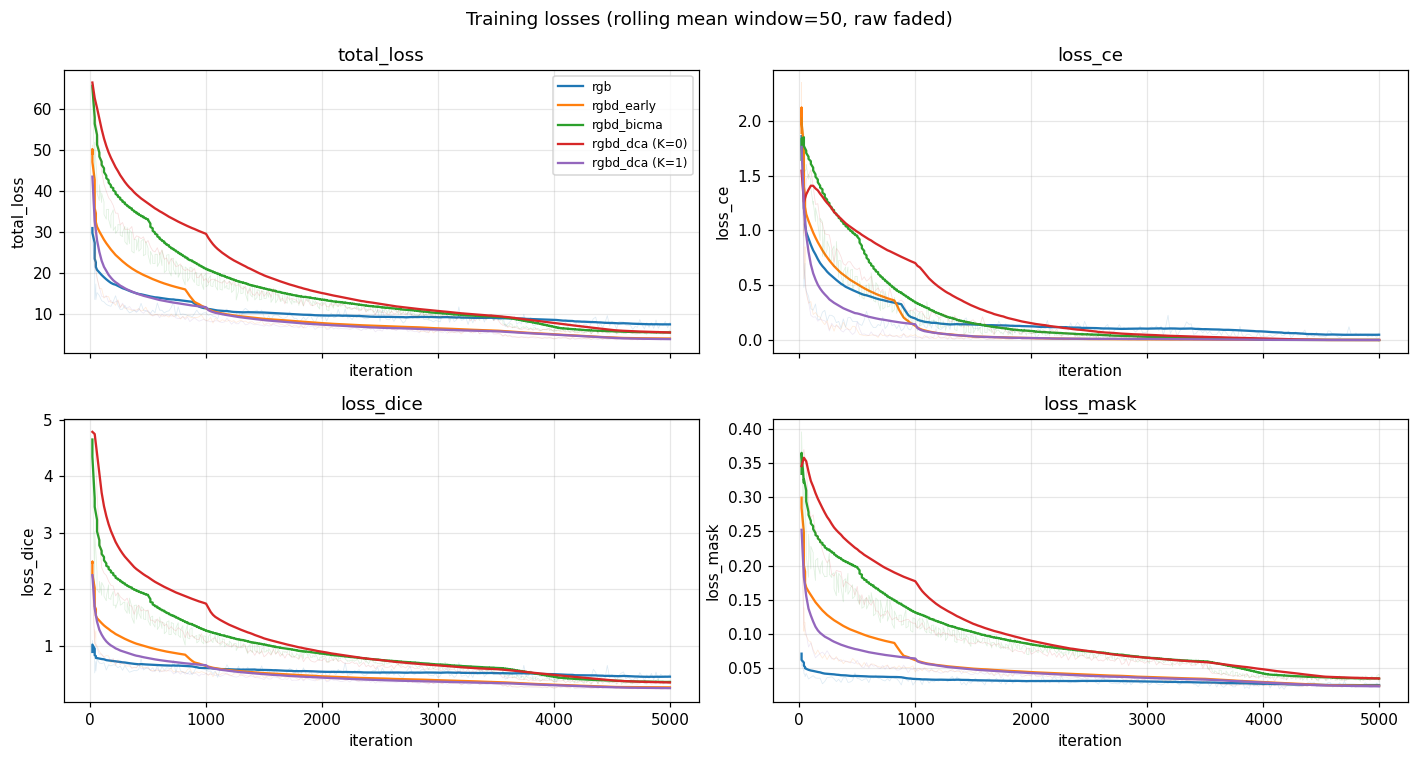

In [7]:
LOSS_COLS = ["total_loss", "loss_ce", "loss_dice", "loss_mask"]
WINDOW = 50

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, col in zip(axes.flat, LOSS_COLS):
    for name, train_df in train_data.items():
        if col not in train_df.columns:
            continue
        smoothed = train_df[col].rolling(WINDOW, min_periods=1).mean()
        line, = ax.plot(train_df["iteration"], smoothed, label=name, linewidth=1.5)
        ax.plot(train_df["iteration"], train_df[col], color=line.get_color(), alpha=0.15, linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel("iteration")
    ax.set_ylabel(col)
axes[0, 0].legend(fontsize=8, loc="best")
fig.suptitle(f"Training losses (rolling mean window={WINDOW}, raw faded)")
fig.tight_layout()
plt.show()

## Final summary bar chart

Grouped bars of best-iter AP / AP50 / AP75 per variant.

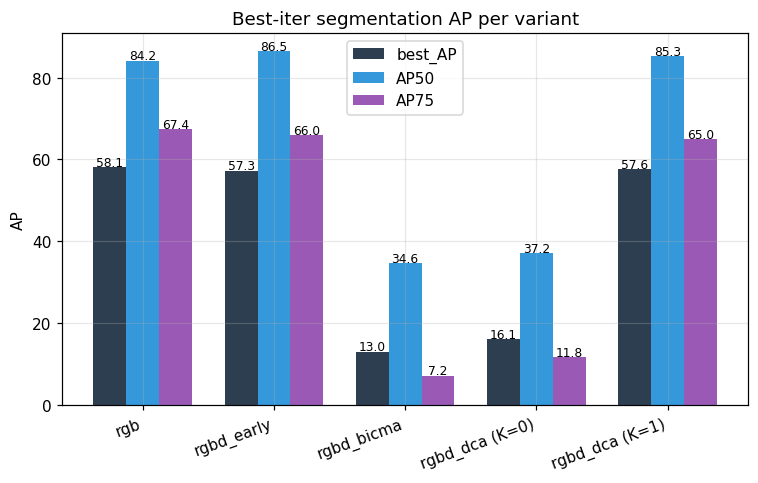

In [8]:
names = list(summary.index)
metrics_to_plot = ["best_AP", "AP50", "AP75"]
colors = ["#2c3e50", "#3498db", "#9b59b6"]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(names)), 4.5))
for i, (m, c) in enumerate(zip(metrics_to_plot, colors)):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, summary[m].values, w, label=m, color=c)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
                f"{b.get_height():.1f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("AP")
ax.set_title("Best-iter segmentation AP per variant")
ax.legend()
fig.tight_layout()
plt.show()